# Experiment 3 - CDC BRFSS Feature Importance Analysis

This experiment tunes LightGBM and XGBoost on the CDC BRFSS dataset and compares their feature importance rankings.

The goal is to identify which features the tuned models rely on most when predicting diabetes.

Models:
- LightGBM
- XGBoost

Main outputs:
- Tuned model performance
- Top feature importance plots
- Feature importance comparison table

In [1]:
#1 Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report
)

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

from IPython.display import display

print("imports successfully loaded")

imports successfully loaded


In [4]:
#2 Clone repo / move into project folder
if not os.path.exists("/content/Predicting-Type-2-Diabetes"):
    !git clone https://github.com/COMP3608-Intelligent-Systems-Project/Predicting-Type-2-Diabetes.git

%cd /content/Predicting-Type-2-Diabetes

/content/Predicting-Type-2-Diabetes


In [5]:
#3 Load CDC BRFSS data
path = "data/raw/diabetes_binary_health_indicators_BRFSS2015.csv"
df = pd.read_csv(path)

X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

print("-" * 50)
print(" Experiment 3: CDC Feature Importance Analysis")
print("-" * 50)
print(f"Dataset shape: {df.shape}")
print(f"Features shape: {X.shape}")
print("\nTarget balance (%):")
print((y.value_counts(normalize=True) * 100).round(2))

df.head()

--------------------------------------------------
 Experiment 3: CDC Feature Importance Analysis
--------------------------------------------------
Dataset shape: (253680, 22)
Features shape: (253680, 21)

Target balance (%):
Diabetes_binary
0.0    86.07
1.0    13.93
Name: proportion, dtype: float64


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [6]:
#4 Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts())

print("\nTest target distribution:")
print(y_test.value_counts())

Train shape: (202944, 21)
Test shape: (50736, 21)

Train target distribution:
Diabetes_binary
0.0    174667
1.0     28277
Name: count, dtype: int64

Test target distribution:
Diabetes_binary
0.0    43667
1.0     7069
Name: count, dtype: int64


In [7]:
#5 Apply SMOTE to training set only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
Diabetes_binary
0.0    174667
1.0     28277
Name: count, dtype: int64

After SMOTE:
Diabetes_binary
0.0    174667
1.0    174667
Name: count, dtype: int64


In [8]:
#6 Create smaller tuning sample for faster RandomizedSearchCV
tuning_sample_size = 60000

X_tune, _, y_tune, _ = train_test_split(
    X_train_smote,
    y_train_smote,
    train_size=tuning_sample_size,
    random_state=42,
    stratify=y_train_smote
)

print("Tuning sample shape:", X_tune.shape)
print("Tuning target balance:")
print(pd.Series(y_tune).value_counts())

Tuning sample shape: (60000, 21)
Tuning target balance:
Diabetes_binary
1.0    30000
0.0    30000
Name: count, dtype: int64


In [11]:
#7 Evaluation helper function
def evaluate_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "AUC-ROC": roc_auc_score(y_test, y_prob)
    }

    print("-" * 50)
    print(f"{model_name} Performance")
    print("-" * 50)
    print(classification_report(y_test, y_pred, zero_division=0))

    return results

print("evaluation helper ready")

evaluation helper ready


In [10]:
#8 Tune LightGBM
print("-" * 50)
print(" Tuning LightGBM")
print("-" * 50)

lgbm_base = LGBMClassifier(
    random_state=42,
    verbosity=-1
)

lgbm_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 5, 10]
}

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=lgbm_param_grid,
    n_iter=8,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

lgbm_search.fit(X_tune, y_tune)

print("Best LightGBM parameters:")
print(lgbm_search.best_params_)

print("\nBest LightGBM CV F1 Score:")
print(round(lgbm_search.best_score_, 4))

--------------------------------------------------
 Tuning LightGBM
--------------------------------------------------
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best LightGBM parameters:
{'num_leaves': 31, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1}

Best LightGBM CV F1 Score:
0.9146


In [12]:
#9 Train final tuned LightGBM on full SMOTE training data
best_lgbm = LGBMClassifier(
    **lgbm_search.best_params_,
    random_state=42,
    verbosity=-1
)

best_lgbm.fit(X_train_smote, y_train_smote)

lgbm_results = evaluate_model(
    "Tuned LightGBM",
    best_lgbm,
    X_test,
    y_test
)

--------------------------------------------------
Tuned LightGBM Performance
--------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.88      0.97      0.93     43667
         1.0       0.54      0.18      0.28      7069

    accuracy                           0.86     50736
   macro avg       0.71      0.58      0.60     50736
weighted avg       0.83      0.86      0.83     50736



In [14]:
#10 Tune XGBoost
print("-" * 50)
print(" Tuning XGBoost")
print("-" * 50)

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=8,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_tune, y_tune)

print("Best XGBoost parameters:")
print(xgb_search.best_params_)

print("\nBest XGBoost CV F1 Score:")
print(round(xgb_search.best_score_, 4))

--------------------------------------------------
 Tuning XGBoost
--------------------------------------------------
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best XGBoost parameters:
{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

Best XGBoost CV F1 Score:
0.9102


In [15]:
#11 Train final tuned XGBoost on full SMOTE training data
best_xgb = XGBClassifier(
    **xgb_search.best_params_,
    random_state=42,
    eval_metric="logloss"
)

best_xgb.fit(X_train_smote, y_train_smote)

xgb_results = evaluate_model(
    "Tuned XGBoost",
    best_xgb,
    X_test,
    y_test
)

--------------------------------------------------
Tuned XGBoost Performance
--------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.88      0.97      0.92     43667
         1.0       0.53      0.21      0.30      7069

    accuracy                           0.86     50736
   macro avg       0.71      0.59      0.61     50736
weighted avg       0.83      0.86      0.84     50736



In [16]:
#12 Tuned model comparison table
results_df = pd.DataFrame([lgbm_results, xgb_results])

print("-" * 60)
print(" Experiment 3 - Tuned Model Comparison")
print("-" * 60)

display(results_df.round(4))

------------------------------------------------------------
 Experiment 3 - Tuned Model Comparison
------------------------------------------------------------


,Model,Accuracy,Precision,Recall,F1 Score,AUC-ROC
0,Tuned LightGBM,0.8647,0.5429,0.1845,0.2754,0.8252
1,Tuned XGBoost,0.8641,0.5319,0.2053,0.2962,0.8234


In [17]:
#13 Extract feature importance from tuned models
lgbm_importance = pd.DataFrame({
    "Feature": X.columns,
    "LightGBM Importance": best_lgbm.feature_importances_
})

xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "XGBoost Importance": best_xgb.feature_importances_
})

# normalize importance values for easier comparison
lgbm_importance["LightGBM Importance Normalized"] = (
    lgbm_importance["LightGBM Importance"] / lgbm_importance["LightGBM Importance"].sum()
)

xgb_importance["XGBoost Importance Normalized"] = (
    xgb_importance["XGBoost Importance"] / xgb_importance["XGBoost Importance"].sum()
)

importance_df = pd.merge(
    lgbm_importance,
    xgb_importance,
    on="Feature"
)

importance_df["Average Importance"] = (
    importance_df["LightGBM Importance Normalized"] +
    importance_df["XGBoost Importance Normalized"]
) / 2

importance_df = importance_df.sort_values("Average Importance", ascending=False)

print("Top combined features:")
display(importance_df.head(10))

Top combined features:


,Feature,LightGBM Importance,LightGBM Importance Normalized,XGBoost Importance,XGBoost Importance Normalized,Average Importance
0,HighBP,747,0.084160,0.177154,0.177154,0.130657
13,GenHlth,1323,0.149054,0.074635,0.074635,0.111845
3,BMI,1342,0.151194,0.019515,0.019515,0.085355
18,Age,1155,0.130126,0.027627,0.027627,0.078876
1,HighChol,478,0.053853,0.100392,0.100392,0.077123
8,Fruits,184,0.020730,0.086061,0.086061,0.053395
4,Smoker,253,0.028504,0.075851,0.075851,0.052178
20,Income,688,0.077512,0.015912,0.015912,0.046712
7,PhysActivity,163,0.018364,0.069977,0.069977,0.044171
19,Education,426,0.047995,0.039686,0.039686,0.043840


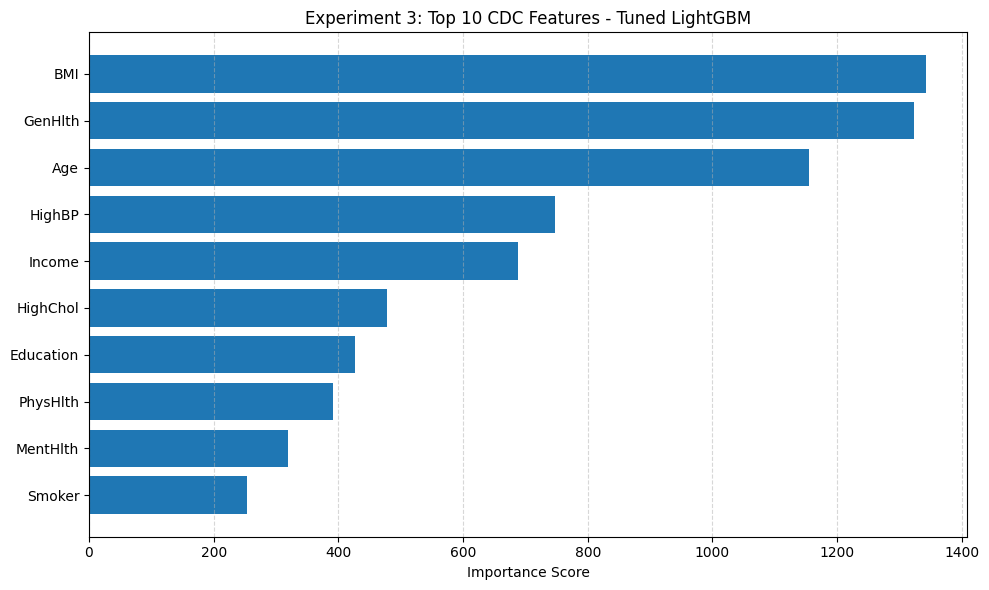

In [18]:
#14 Plot LightGBM feature importance
top_lgbm = lgbm_importance.sort_values(
    "LightGBM Importance",
    ascending=True
).tail(10)

plt.figure(figsize=(10, 6))
plt.barh(top_lgbm["Feature"], top_lgbm["LightGBM Importance"])
plt.title("Experiment 3: Top 10 CDC Features - Tuned LightGBM")
plt.xlabel("Importance Score")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

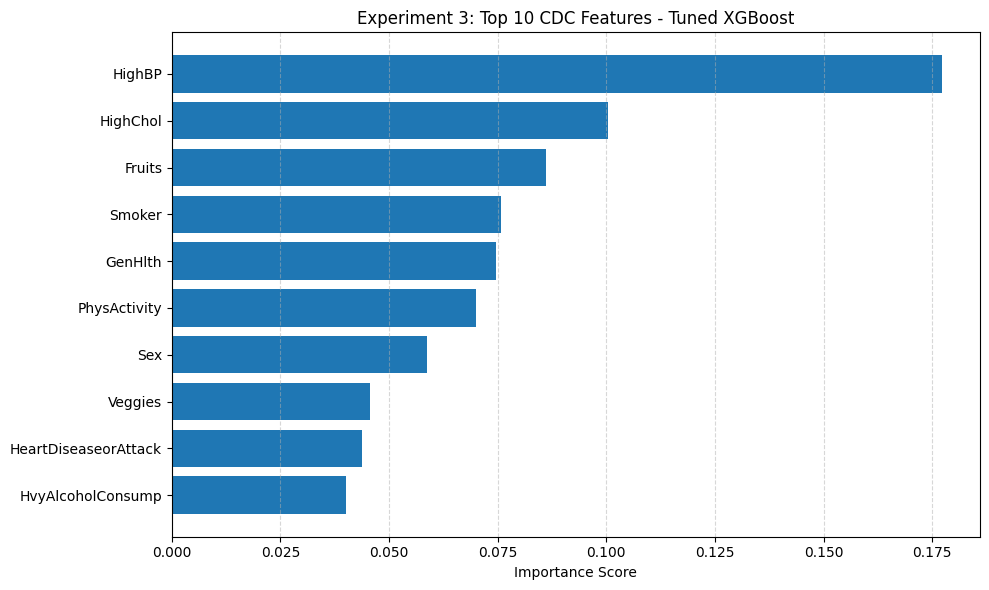

In [19]:
#15 Plot XGBoost feature importance
top_xgb = xgb_importance.sort_values(
    "XGBoost Importance",
    ascending=True
).tail(10)

plt.figure(figsize=(10, 6))
plt.barh(top_xgb["Feature"], top_xgb["XGBoost Importance"])
plt.title("Experiment 3: Top 10 CDC Features - Tuned XGBoost")
plt.xlabel("Importance Score")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

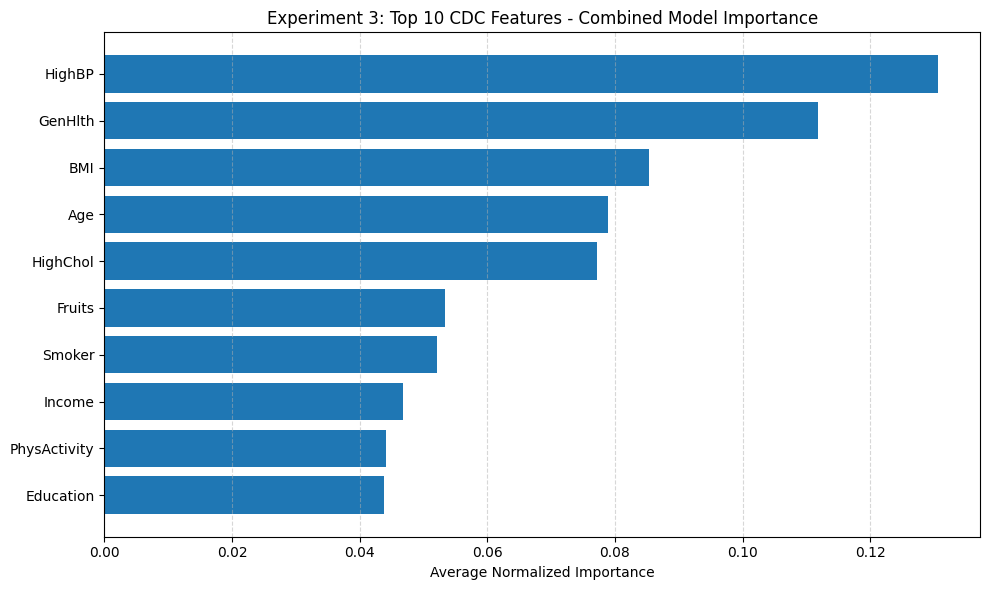

In [20]:
#16 Combined feature importance plot
top_combined = importance_df.sort_values(
    "Average Importance",
    ascending=True
).tail(10)

plt.figure(figsize=(10, 6))
plt.barh(top_combined["Feature"], top_combined["Average Importance"])
plt.title("Experiment 3: Top 10 CDC Features - Combined Model Importance")
plt.xlabel("Average Normalized Importance")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()